In [5]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek


c:\Users\haris\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
pip install seaborn shap xgboost lightgbm


  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.50.0-cp313-cp313-win_amd64.whl (549 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 24.7 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ------ --------------------------------- 6.3/38.1 MB 30.4 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/38.1 MB 30.6 MB/s eta 0:00:01
   -------------- ------------------------- 13.4/38.1 MB 21.5 MB/s eta 0:00:02
   ------------------ --------------------- 17

In [2]:
pip install matplotlib


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.1 MB 34.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 31.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 24.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------

In [6]:
df = pd.read_csv(r"D:\Bank Churn Prediction\Churn_Modelling.csv")
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)
df=pd.get_dummies(df,drop_first=True)
X=df.drop("Exited",axis=1)
y=df["Exited"]
print(X.columns)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')


In [7]:
#train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [8]:
#Smote+tomek combo
smote_tomek=SMOTETomek(random_state=42)
X_train_bal,y_train_bal=smote_tomek.fit_resample(X_train,y_train)

In [9]:
#scaling
scaler=StandardScaler()
X_train_bal=scaler.fit_transform(X_train_bal)
x_test_scaled=scaler.transform(X_test)

In [10]:
#Models
rf=RandomForestClassifier(n_estimators=600,max_depth=14,min_samples_leaf=3,class_weight={0:1,1:2},random_state=42)
xgb=XGBClassifier(n_estimators=400,learning_rate=0.05,max_depth=6,
                  subsample=0.9,colsample_bytree=0.9,scale_pos_weight=5,eval_metric='logloss',random_state=42)
lgbm=LGBMClassifier(n_estimators=400,learning_rate=0.05,max_depth=6,class_weight={0:1,0:2},random_state=42)


In [11]:
#ensemble
ensemble=VotingClassifier(estimators=[('rf',rf),('xgb',xgb),('lgbm',lgbm)],voting='soft',weights=[2,3,3])
ensemble.fit(X_train_bal,y_train_bal)

[LightGBM] [Info] Number of positive: 5439, number of negative: 5439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 10878, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,"[2, 3, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,600
,criterion,'gini'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,3


In [12]:
#Evaluation
X_test_scaled=scaler.transform(X_test)
y_prob=ensemble.predict_proba(X_test_scaled)[:,1]
threshold=0.45
y_pred=(y_prob>threshold).astype(int)
print("Threshold:",threshold)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Threshold: 0.45
Accuracy: 0.784
              precision    recall  f1-score   support

           0       0.92      0.80      0.85      1593
           1       0.48      0.73      0.58       407

    accuracy                           0.78      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.78      0.80      2000



c:\Users\haris\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


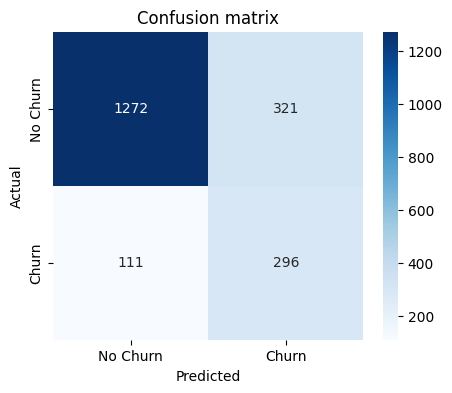

In [13]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [14]:
#bank loss prediction
test_df = X_test.copy()
test_df['Actual_Churn'] = y_test.values
test_df['Predicted_Churn'] = y_pred
test_df['Churn_Probability'] = y_prob

# Bank loss calculation
test_df['Expected_Loss'] = test_df['Balance'] * test_df['Predicted_Churn']

total_loss = test_df['Expected_Loss'].sum()
print("Estimated Bank Loss:", total_loss)

Estimated Bank Loss: 58968501.39


In [15]:
import pickle

# Save ensemble model
with open("ensemble_model.pkl", "wb") as f:
    pickle.dump(ensemble, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Ensemble model & scaler saved successfully")


✅ Ensemble model & scaler saved successfully


In [16]:
xgb.fit(X_train_bal,y_train_bal)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [17]:
import pickle
xgb.fit(X_train_bal,y_train_bal)
with open("xgb_model.pkl","wb") as f:
  pickle.dump(xgb,f)

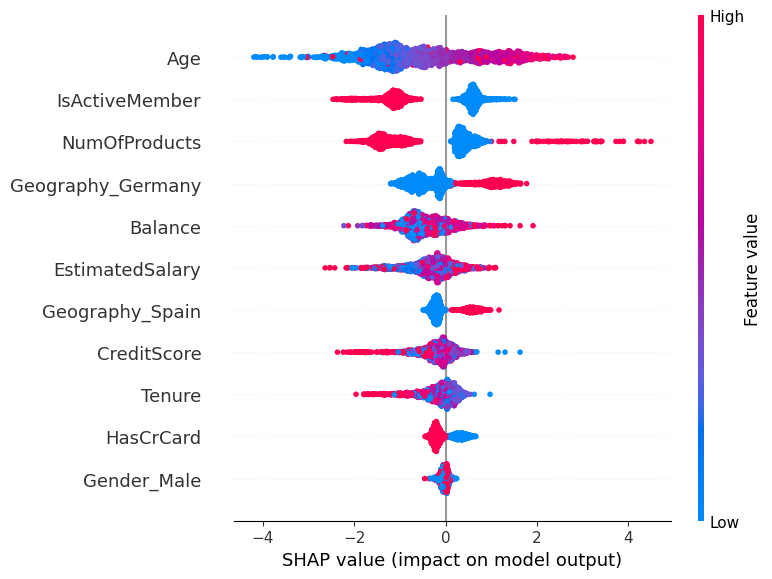

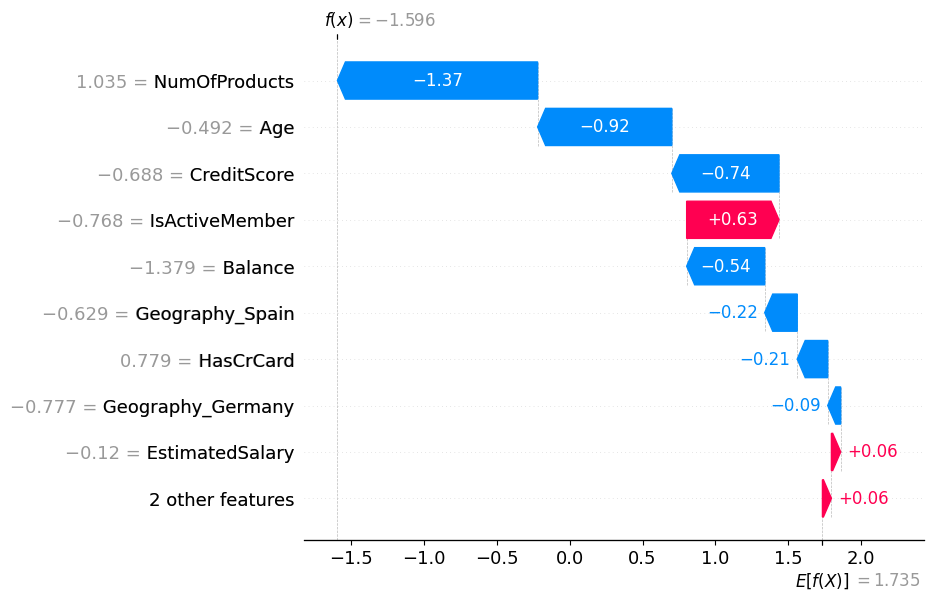

In [18]:
#shap explainability
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Global explanation
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
#Individual customer explanation
i = 0  # customer index
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test_scaled[i],
        feature_names=X.columns
    )
)